# Russian Loanwords in Georgian

This notebook analyzes a manually annotated dataset of Russian loanwords in the Georgian language. The goal is to count how many loanwords appear in each semantic category and calculate the percentage of the dataset represented by each category

**Files needed in the same folder:**
- `russianloans.py`
- this notebook

## 1. Load the dataset

The dataset is stored in `russianloans.py` as a Python dictionary named `russianloans_dictionary`. Each Georgian word is a key, and each value is another dictionary with transliteration, IPA, Russian source form, English gloss, and category.

In [9]:
# Importing dataset from russianloans.py
from russianloans import data

# Check how many loanwords are in the dataset
print("Total entries in the dataset:", len(data))

Total entries in the dataset: 100


## 2. Preview of a few entries

In [14]:
for i, (word, info) in enumerate(data.items()):
    print(word, "→", info)
    if i == 4:
        break

აბაკი → {'transliteration': "abak'i", 'ipa': '[äbäkʼi]', 'russian': 'абак', 'english': 'abacus', 'category': 'institutional'}
აბაჟური → {'transliteration': 'abazhuri', 'ipa': '[äbäʒuɾi]', 'russian': 'абажур', 'english': 'lampshade', 'category': 'everyday'}
აბატი → {'transliteration': "abat'i", 'ipa': '[äbätʼi]', 'russian': 'аббат', 'english': 'abbot', 'category': 'religion'}
აბონემენტი → {'transliteration': "abonement'i", 'ipa': '[äbənəməntʼi]', 'russian': 'абонемент', 'english': 'subscription; season ticket', 'category': 'institutional'}
აბონენტი → {'transliteration': "abonent'i", 'ipa': '[äbo̞ne̞ntʼi]', 'russian': 'абонент', 'english': 'subscriber', 'category': 'everyday'}


## 3. Loanwords count by semantic category

This loop goes through every loanword, reads its `category`, and counts how many times each category appears.

In [15]:
# Create an empty dictionary to store category counts
category_counts = {}

# Loop through every word and its information
for word, info in data.items():
    # Read the category, remove extra spaces, and make it lowercase
    category = info["category"].strip().lower()

    # If the category is blank, label it as unclassified
    if category == "":
        category = "unclassified"

    # If this category is not in the count dictionary yet, start it at 0
    if category not in category_counts:
        category_counts[category] = 0

    # Add 1 to the count for this category
    category_counts[category] += 1

# Show the results, sorted from most frequent to least frequent
print("Category counts:")
for category, count in sorted(category_counts.items(), key=lambda x: x[1], reverse=True):
    print(f"{category}: {count}")

Category counts:
institutional: 26
military: 23
everyday: 17
culture: 14
other: 11
economy: 6
religion: 3


## 4. Calculate percentages

The proportion of the whole dataset represented by each category.

In [16]:
# Calculate the total number of categorized words
total = sum(category_counts.values())

print("Total words:", total)
print("Percentages:")

# Calculate and print the percentage for each category
for category, count in sorted(category_counts.items(), key=lambda x: x[1], reverse=True):
    percent = (count / total) * 100
    print(f"{category}: {percent:.2f}%")

Total words: 100
Percentages:
institutional: 26.00%
military: 23.00%
everyday: 17.00%
culture: 14.00%
other: 11.00%
economy: 6.00%
religion: 3.00%


## 5. Results table

In [17]:
import pandas as pd

results = []

for category, count in sorted(category_counts.items(), key=lambda x: x[1], reverse=True):
    percent = (count / total) * 100
    results.append({
        "Category": category,
        "Count": count,
        "Percentage": round(percent, 2)
    })

results_df = pd.DataFrame(results)
results_df

,Category,Count,Percentage
0,institutional,26,26.0
1,military,23,23.0
2,everyday,17,17.0
3,culture,14,14.0
4,other,11,11.0
5,economy,6,6.0
6,religion,3,3.0


## 5. Bar chart

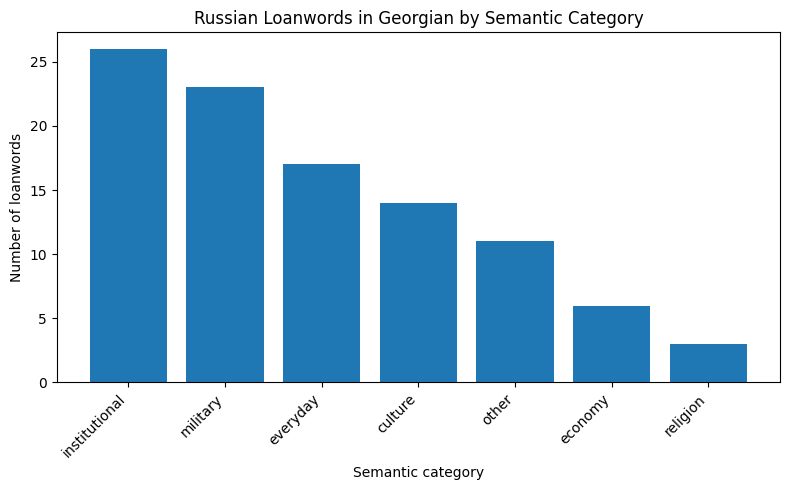

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.bar(results_df["Category"], results_df["Count"])
plt.xlabel("Semantic category")
plt.ylabel("Number of loanwords")
plt.title("Russian Loanwords in Georgian by Semantic Category")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 7. Exporting results

In [19]:
# Save the results table as a CSV file
results_df.to_csv("loanword_category_results.csv", index=False, encoding="utf-8-sig")

print("Saved: loanword_category_results.csv")

Saved: loanword_category_results.csv


## Interpretation

- The concentration of loanwords in institutional and military domains suggests that lexical borrowing was particularly strong in areas associated with government, administration, the military, and the penitentiary system.
- The large number of institutional and military loanwords is consistent with periods of sustained Russian influence over Georgia, particularly during the Russian Empire and the Soviet Union, when many Georgians served in the Russian military. During these periods, Russian also functioned as the primary language of administration, education, and interethnic communication, serving as the lingua franca of the Soviet Union.
- Everyday and cultural vocabulary also show evidence of borrowing, although to a lesser extent.
- Economic and religious vocabulary represent relatively small portions of the annotated dataset.

**Limitations:**
- The dataset contains only 100 manually annotated loanwords, making it a relatively small sample.
- Some loanwords could reasonably be assigned to more than one semantic category.
- The dataset is based on Wiktionary, a lexicographic resource rather than a frequency-based corpus.
- The analysis measures the distribution of documented loanwords, not their frequency of use in contemporary Georgian.


